In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from sklearn.cluster import KMeans
from sklearn.cluster import MeanShift
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix

In [2]:
import astroML as aML

Let's look at the latest database of Gamma Ray Bursts.

 - The database can be downloaded at https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt
 - You can find the physical meaning of each variable at https://user-web.icecube.wisc.edu/~grbweb_public/Variables.html 


This edition of "get your hands dirty" is very open ended (we're getting closer and closer to real research...). You have a cool dataset, explore it! Play with the data, apply some of the tecniques we have seen in classes so far, etc. **Be creative! You're discovering**


Some relevant physical questions you might want to tackle include:

- Does the distribution contain different sub-populations? How many?
- What's the threshold between the classes?
- If you try two clustering methods, do you get more or less the same?
- How do methods respond to outliers?
- What variable(s) shows the multi-modality more evidently?
- Are all GRBs equally likely to be observed? 



In [3]:
import requests

# Download file
r = requests.get('https://user-web.icecube.wisc.edu/~grbweb_public/Summary_table.txt')
with open("Summary_table.txt", 'wb') as f:
    f.write(r.content)

# Read content
data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')

# Read headers
with open("Summary_table.txt",'r') as f:
    names = np.array([n.strip().replace(" ","_") for n in f.readlines()[1].replace("#","").replace("\n","").lstrip().split('    ') if n.strip()!=''])

C:\Users\annat\AppData\Local\Temp\ipykernel_1456\3973052632.py:9: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Summary_table.txt", dtype='str',unpack='True')


In [4]:
data

array([['GRB260707A', 'GRB260706A', 'GRB260705B', ..., 'GRB910424A*',
        'GRB910423A*', 'GRB910421A*'],
       ['None', 'GRB260706675', 'GRB260705949', ..., 'None', 'None',
        'None'],
       ['3:25:09', '16:12:21', '22:46:12.240', ..., '19:43:25.064',
        '19:51:15.804', '9:14:03.800'],
       ...,
       ['-999', '16.8110', '83.4570', ..., '3.1360', '208.5760',
        '5.6960'],
       ['True', 'True', 'True', ..., 'False', 'False', 'False'],
       ['61228.14246528', '61227.67524306', '61226.94875278', ...,
        '48370.82181787', '48369.82726625', '48367.38476620']],
      shape=(15, 9162), dtype='<U14')

In [5]:
data.shape

(15, 9162)

In [6]:
names

array(['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
       'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
       'redshift', "'T100'", 'GBM_located', 'mjd_(T0)'], dtype='<U14')

In [7]:
data_merged=dict(zip(names,data))
for label in ['T90', 'T90_error', "'T100'", 'fluence', 'fluence_error']:
    data_merged[label] = np.array(data_merged[label],dtype='float')

 ## KMeans

Start doing some naif exploration of data by trying a 2 cluster fit (as I know from theory there should be two types, long and short GRBs)

C:\Users\annat\AppData\Local\Temp\ipykernel_1456\3990865622.py:1: RuntimeWarning: invalid value encountered in log10
  log_T90 = np.log10(data_merged["T90"])
C:\Users\annat\AppData\Local\Temp\ipykernel_1456\3990865622.py:2: RuntimeWarning: divide by zero encountered in log10
  log_fluence = np.log10(data_merged['fluence'])
C:\Users\annat\AppData\Local\Temp\ipykernel_1456\3990865622.py:2: RuntimeWarning: invalid value encountered in log10
  log_fluence = np.log10(data_merged['fluence'])


Text(0, 0.5, 'log10(fluence)')

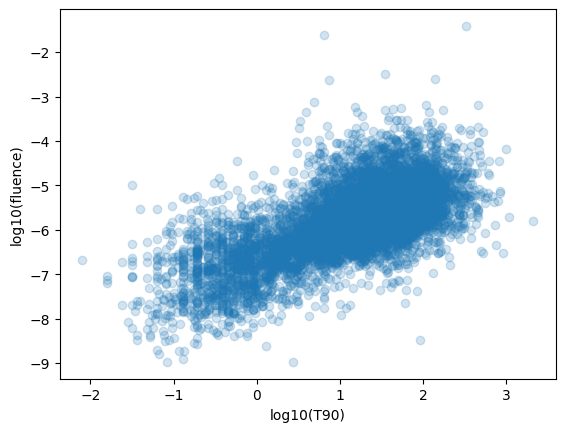

In [8]:
log_T90 = np.log10(data_merged["T90"])
log_fluence = np.log10(data_merged['fluence'])
index_to_cut = np.where(np.isnan(log_T90) | np.isinf(log_T90))[0]
log_T90 = np.delete(log_T90, index_to_cut)
log_fluence = np.delete(log_fluence, index_to_cut)
index_to_cut =   np.where(np.isnan(log_fluence) | np.isinf(log_fluence))[0]
log_T90 = np.delete(log_T90, index_to_cut)
log_fluence = np.delete(log_fluence, index_to_cut)

plt.scatter(log_T90, log_fluence, alpha=0.2)
plt.xlabel('log10(T90)')
plt.ylabel('log10(fluence)')

In [9]:
X = np.stack((log_T90, log_fluence)).T

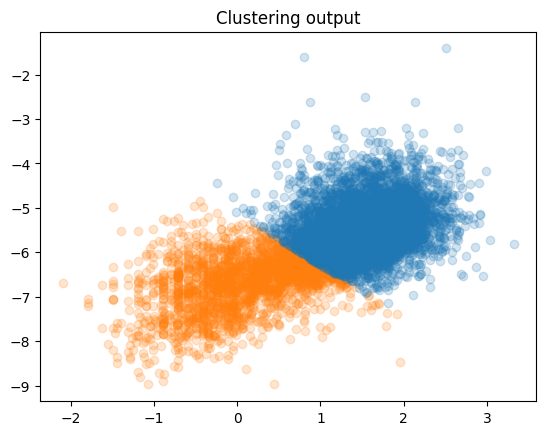

In [10]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X[labels==ii,0], X[labels==ii,1], 
                color=colors[ii],alpha=0.2)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');

In [11]:
import os
import warnings

# Just things to take away all the error messages
os.environ['OMP_NUM_THREADS'] = '1' 
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

In [12]:
centers

array([[ 0.08904983, -6.6955517 ],
       [ 1.52728242, -5.43990944]])

Cross validation for the number of clusters. I've used Grid Search algorithm to do 5 folds of validation on a score metric based on silhouette value. I found it is used to define the goodness of clustering divisions: it computes the score in a geometrical fashion, I'd say, looking at its shape. distance from center of it and from neighbours.

In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score

# Numbers to test
k_range = range(2, 10)

# Function to define a score by using Silhoutte, higher it is the better (and GridSearch takes
# the maximum)
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    # At least 2 clusters
    if len(np.unique(labels)) < 2:
        return -1 
    return silhouette_score(X, labels)

# GridSearch with 5 folds
grid_km = GridSearchCV(
    KMeans(n_init='auto', random_state=42),
    param_grid={'n_clusters': k_range},
    scoring=silhouette_scorer,
    cv=5 
)

# Fit on data
grid_km.fit(X)

best_k = grid_km.best_params_['n_clusters']
print(f"The best number of clusters for KMeans from Cross Validation is: {best_k}")

The best number of clusters for KMeans from Cross Validation is: 2


## MeanShift

Start by prepocessing and standardizing data and performing an estimation for the best bandwith of the 2d kde describing the data

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [22]:
from sklearn.cluster import estimate_bandwidth

# increment quantile to merge small clusters together
bw = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=200)

ms = MeanShift(bandwidth=bw, bin_seeding=True)#, cluster_all=False)#, min_bin_freq=3)
ms.fit(X_scaled)

print(f"Best bandwidth: {bw:.3f}")
print(f"Clusters found: {len(np.unique(ms.labels_))}")

Best bandwidth: 0.954
Clusters found: 3


[0 1 2]


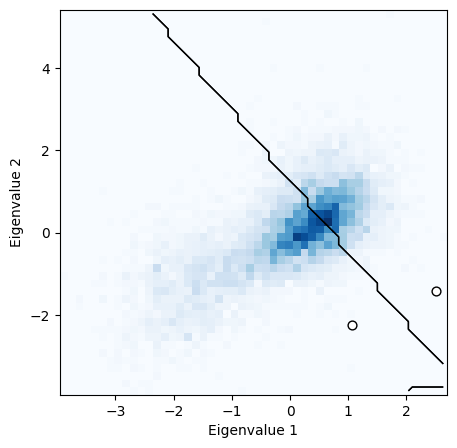

In [23]:
labels_unique = np.unique(ms.labels_)
n_clusters = len(labels_unique[labels_unique >= 0])
print(labels_unique)

# Make some plots
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot()

# Compute a 2D histogram  of the input
H, xedges, yedges = np.histogram2d(X_scaled[:,0], X_scaled[:,1], 50)

# plot density
ax.imshow(H.T, origin='lower', interpolation='nearest', aspect='auto',
          extent=[xedges[0], xedges[-1],
                  yedges[0], yedges[-1]],
          cmap='Blues')

# plot cluster centers
cluster_centers = scaler.inverse_transform(ms.cluster_centers_)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           s=40, c='w', edgecolors='k')

# plot cluster boundaries
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

Xgrid = np.meshgrid(x_centers, y_centers)
Xgrid = np.array(Xgrid).reshape((2, 50 * 50)).T

H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

for i in range(n_clusters):
    Hcp = H.copy()
    flag = (Hcp == i)
    Hcp[flag] = 1
    Hcp[~flag] = 0

    ax.contour(x_centers, y_centers, Hcp, [-0.5, 0.5],
               linewidths=1, colors='k')
 
    H = ms.predict(scaler.transform(Xgrid)).reshape((50, 50))

ax.set_xlim(xedges[0], xedges[-1])
ax.set_ylim(yedges[0], yedges[-1])

ax.set_xlabel('Eigenvalue 1')
ax.set_ylabel('Eigenvalue 2')

plt.show()

In [25]:
centers

array([[ 0.41881983,  0.22510742],
       [-0.06469546,  4.38002089],
       [ 1.70543463,  5.40793457]])

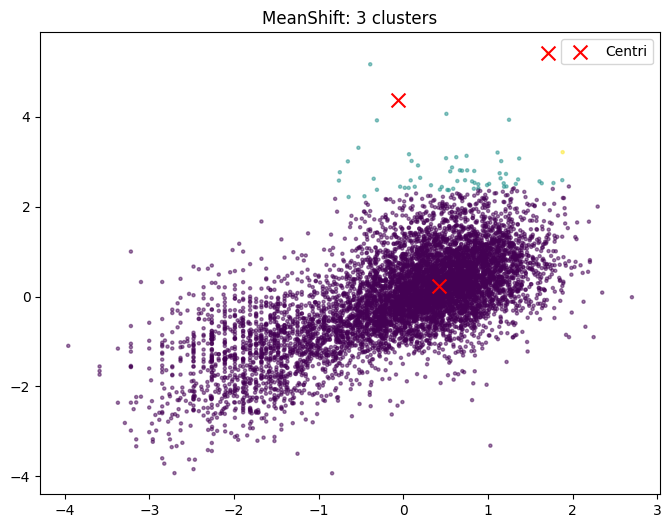

In [26]:
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=ms.labels_, s=5, cmap='viridis', alpha=0.5)
centers = ms.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100, label='Centri')
plt.title(f"MeanShift: {len(np.unique(ms.labels_))} clusters")
plt.legend()
plt.show()

In [27]:
centers

array([[ 0.41881983,  0.22510742],
       [-0.06469546,  4.38002089],
       [ 1.70543463,  5.40793457]])

(array([7.408e+03, 2.480e+02, 9.100e+01, 4.400e+01, 1.000e+01, 1.000e+01,
        9.000e+00, 4.000e+00, 3.000e+00, 2.000e+00]),
 array([0.   , 0.003, 0.006, 0.009, 0.012, 0.015, 0.018, 0.021, 0.024,
        0.027, 0.03 ]),
 <BarContainer object of 10 artists>)

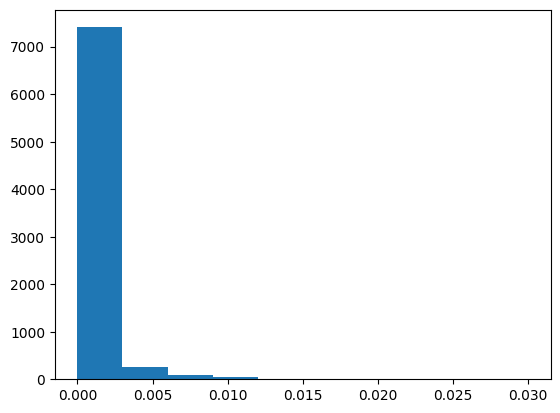

In [28]:
plt.hist(np.diff(np.sort(X_scaled[:,0])), range=(0,0.03))

In [29]:
np.mean(np.diff(np.sort(X_scaled[:,0])))

np.float64(0.0008482219520963757)

## DB scan only tried, no results

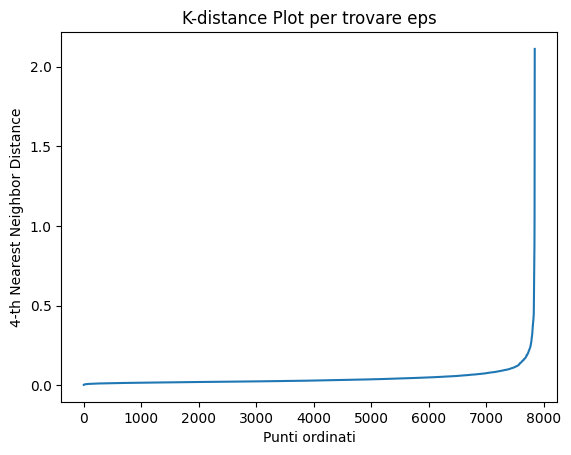

In [30]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# 1. Calcolo della distanza dai k vicini per trovare eps
# Un buon valore per k è 2 * dimensioni_dati = 4
neigh = NearestNeighbors(n_neighbors=4)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

# Ordiniamo le distanze e plotteiamole
distances = np.sort(distances[:, 3], axis=0)
plt.plot(distances)
plt.ylabel('4-th Nearest Neighbor Distance')
plt.xlabel('Punti ordinati')
plt.title('K-distance Plot to find eps')
plt.show()

Cluster trovati: 1
Numero di cluster stimati: 1


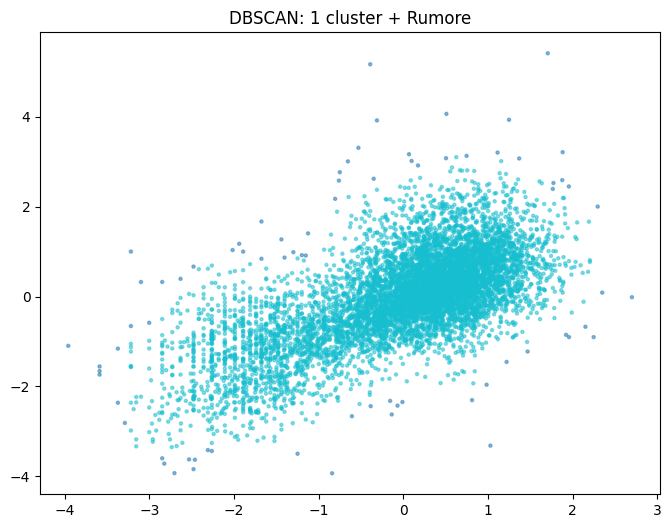

In [35]:

# Prova a ridurre eps e aumentare min_samples contemporaneamente
db = DBSCAN(eps=0.3, min_samples=10) 
labels_db = db.fit_predict(X_scaled)

print(f"Cluster trovati: {len(np.unique(labels_db[labels_db != -1]))}")

# Nota: le label -1 sono considerate "Rumore" (Outliers)
n_clusters_ = len(set(labels_db)) - (1 if -1 in labels_db else 0)
print(f'Numero di cluster stimati: {n_clusters_}')

# Visualizzazione
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_db, s=5, cmap='tab10', alpha=0.5)
plt.title(f"DBSCAN: {n_clusters_} cluster + Rumore")
plt.show()

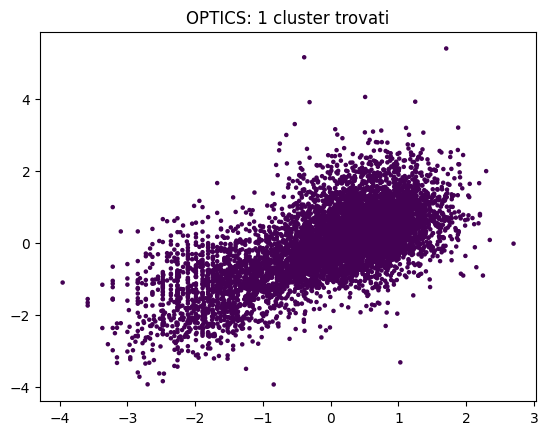

In [36]:
from sklearn.cluster import OPTICS

# OPTICS non richiede eps, cerca di capire la struttura gerarchica
op = OPTICS(min_samples=30, xi=0.05, min_cluster_size=0.05)
labels_op = op.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels_op, s=5, cmap='viridis')
plt.title(f"OPTICS: {len(np.unique(labels_op[labels_op != -1]))} cluster trovati")
plt.show()

In [38]:
from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.15, min_samples=10).fit(X_scaled)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 4
Estimated number of noise points: 394


In [44]:
# Nota: usiamo log10(2) perché i nostri dati X sono in scala logaritmica
log_threshold = np.log10(1.0)

# y_true sarà 1 per i Long e 0 per i Short
# Assumiamo che X[:, 0] sia la colonna dei log_T90
y_true = (X[:, 0] <= log_threshold).astype(int)

In [45]:
y_true

array([0, 0, 1, ..., 0, 0, 0], shape=(7848,))

In [46]:
print(f"Homogeneity: {metrics.homogeneity_score(y_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(y_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(y_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(y_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(y_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X_scaled, labels):.3f}")

Homogeneity: 0.041
Completeness: 0.069
V-measure: 0.051
Adjusted Rand Index: 0.148
Adjusted Mutual Information: 0.050
Silhouette Coefficient: -0.070


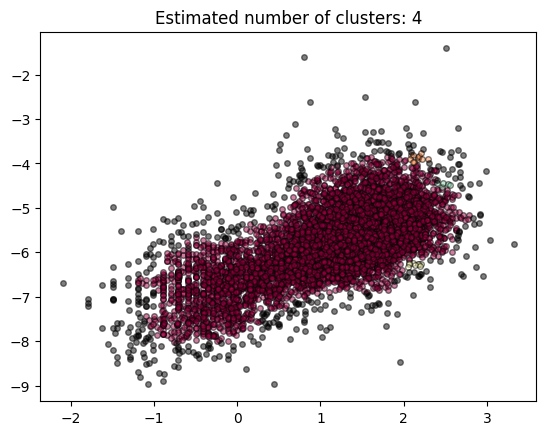

In [47]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=4, alpha=0.5
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=4, alpha=0.5
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

## Test and training

In [48]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.model_selection import KFold

# Metodo statistico: stima basata sui quantili dei dati
best_bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=500)
print(f"Stima ottimale della bandwidth: {best_bandwidth:.3f}")

ms = MeanShift(bandwidth=best_bandwidth, bin_seeding=True)
ms.fit(X)

Stima ottimale della bandwidth: 0.762


,"bandwidth bandwidth: float, default=NoneBandwidth used in the flat kernel.If not given, the bandwidth is estimated usingsklearn.cluster.estimate_bandwidth; see the documentation for thatfunction for hints on scalability (see also the Notes, below).",np.float64(0.7618054104677288)
,"seeds seeds: array-like of shape (n_samples, n_features), default=NoneSeeds used to initialize kernels. If not set,the seeds are calculated by clustering.get_bin_seedswith bandwidth as the grid size and default values forother parameters.",None
,"bin_seeding bin_seeding: bool, default=FalseIf true, initial kernel locations are not locations of allpoints, but rather the location of the discretized version ofpoints, where points are binned onto a grid whose coarsenesscorresponds to the bandwidth. Setting this option to True will speedup the algorithm because fewer seeds will be initialized.The default value is False.Ignored if seeds argument is not None.",True
,"min_bin_freq min_bin_freq: int, default=1To speed up the algorithm, accept only those bins with at leastmin_bin_freq points as seeds.",1
,"cluster_all cluster_all: bool, default=TrueIf true, then all points are clustered, even those orphans that arenot within any kernel. Orphans are assigned to the nearest kernel.If false, then orphans are given cluster label -1.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. The following tasks benefitfrom the parallelization:- The search of nearest neighbors for bandwidth estimation and label assignments. See the details in the docstring of the ``NearestNeighbors`` class.- Hill-climbing optimization for all seeds.See :term:`Glossary ` for more details.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"max_iter max_iter: int, default=300Maximum number of iterations, per seed point before the clusteringoperation terminates (for that seed point), if has not converged yet... versionadded:: 0.22",300


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split 80/20
X_train, X_test = train_test_split(X, test_size=0.5)#, random_state=42)

# Training sul 80%
km_final = KMeans(n_clusters=2, n_init='auto').fit(X_train)

# Valutazione: assegniamo i punti del test set ai cluster trovati nel training
y_test_pred = km_final.predict(X_test)

# Se vuoi un'accuratezza numerica rispetto alla soglia fisica di 2s (T90):
log_threshold = np.log10(2.0)
y_test_true = (X_test[:, 0] > log_threshold).astype(int)

# Allineamento etichette (per evitare che 0 e 1 siano scambiati)
if km_final.cluster_centers_[0, 0] > km_final.cluster_centers_[1, 0]:
    y_test_pred = 1 - y_test_pred

acc = accuracy_score(y_test_true, y_test_pred)
print(f"Accuratezza del clustering (vs fisica): {acc:.2%}")

Accuratezza del clustering (vs fisica): 88.63%


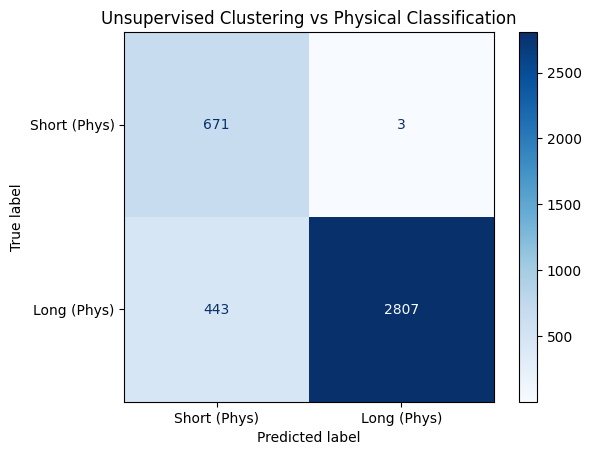

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calcolo della matrice
cm = confusion_matrix(y_test_true, y_test_pred)

# Visualizzazione
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Short (Phys)', 'Long (Phys)'])
disp.plot(cmap='Blues')
plt.title('Unsupervised Clustering vs Physical Classification')
plt.show()

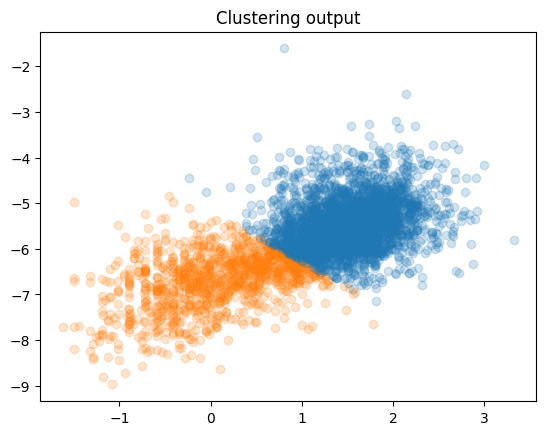

In [52]:
centers = km_final.cluster_centers_ #location of the clusters


# plot the data color-coded by cluster id
colors = ['C1', 'C0', 'C2']
for ii in range(3):
    plt.scatter(X_test[y_test_pred==ii,0], X_test[y_test_pred==ii,1], 
                color=colors[ii],alpha=0.2)

# To get some information on these try:
# KMeans?
# help(clf)
plt.title('Clustering output');

## Correlation

In [53]:

import pandas as pd
from astroML.correlation import two_point

# nomi delle colonne basati sulla tua descrizione
cols = ['GRB_name', 'GRB_name_Fermi', 'T0', 'ra', 'decl', 'pos_error',
        'T90', 'T90_error', 'T90_start', 'fluence', 'fluence_error',
        'redshift', 'T100', 'GBM_located', 'mjd_T0']

# Supponendo che 'data_array' sia il tuo array shape (15, 9090)
df = pd.DataFrame(data.T, columns=cols)

# Convertiamo in numerico le colonne necessarie (gestendo eventuali errori)
numeric_cols = ['ra', 'decl', 'T90', 'fluence']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Rimuoviamo righe con NaN (fondamentale per l'analisi di correlazione)
df_clean = df.dropna(subset=['ra', 'decl', 'T90'])

c:\Users\annat\anaconda3\envs\astro_env\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


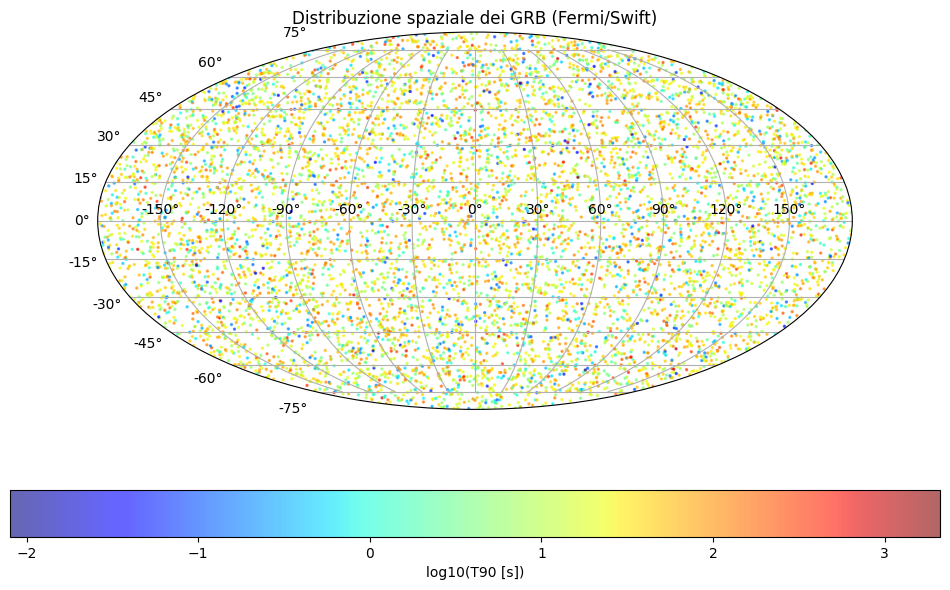

In [54]:
plt.figure(figsize=(12, 7))
ax = plt.subplot(111, projection='mollweide')

# Conversione RA/Dec in radianti
ra_rad = np.remainder(np.deg2rad(df_clean['ra']) + np.pi, 2*np.pi) - np.pi
dec_rad = np.deg2rad(df_clean['decl'])

# Usiamo il logaritmo del T90 per vedere meglio la distinzione Short/Long
sc = ax.scatter(ra_rad, dec_rad, c=np.log10(df_clean['T90']), 
                s=2, cmap='jet', alpha=0.6)

plt.colorbar(sc, label='log10(T90 [s])', orientation='horizontal')
plt.grid(True)
plt.title("Distribuzione spaziale dei GRB (Fermi/Swift)")
plt.show()

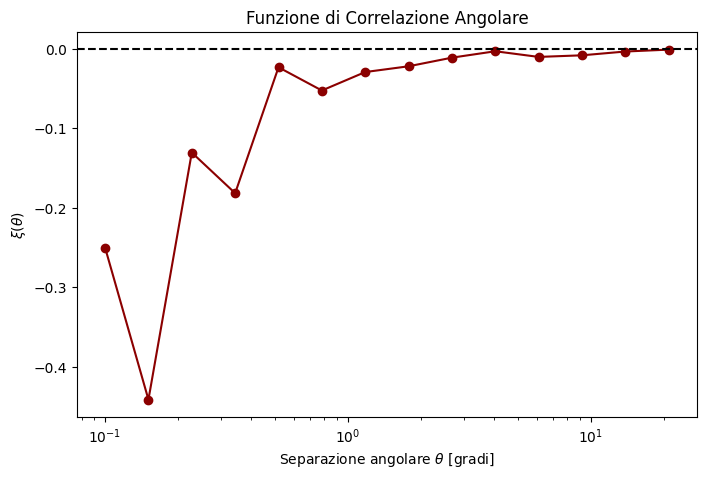

In [55]:
from astroML.correlation import two_point

# Prepariamo le coordinate sulla sfera
coords = df_clean[['ra', 'decl']].values

# Definiamo i bin angolari (in gradi)
bins = np.logspace(-1, 1.5, 15)

# Calcoliamo la correlazione
# Questa funzione confronta la distribuzione reale con una casuale (Random)
corr = two_point(coords, bins, method='landy-szalay')

plt.figure(figsize=(8, 5))
plt.semilogx(bins[:-1], corr, 'o-', color='darkred')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Separazione angolare $\\theta$ [gradi]')
plt.ylabel('$\\xi(\\theta)$')
plt.title('Funzione di Correlazione Angolare')
plt.show()

In [58]:
clf = KMeans(n_clusters=2,n_init='auto') #Try 2 clusters to start with
clf.fit(X)
centers = clf.cluster_centers_ #location of the clusters
labels = clf.predict(X) #labels for each of the points

In [59]:
# Assumiamo che X_scaled siano i tuoi dati [log_T90, log_fluence] standardizzati
# e labels_km siano le etichette del KMeans (0 per una classe, 1 per l'altra)

# Identifichiamo chi è Short e chi è Long in base al T90 medio
# use existing KMeans labels
labels_km = labels
centroid_0 = X_scaled[labels_km == 0].mean(axis=0)
centroid_1 = X_scaled[labels_km == 1].mean(axis=0)

if centroid_0[0] < centroid_1[0]:
    X_short = X_scaled[labels_km == 0]
    X_long = X_scaled[labels_km == 1]
else:
    X_short = X_scaled[labels_km == 1]
    X_long = X_scaled[labels_km == 0]

print(f"Short GRBs: {len(X_short)} | Long GRBs: {len(X_long)}")

Short GRBs: 2129 | Long GRBs: 5719


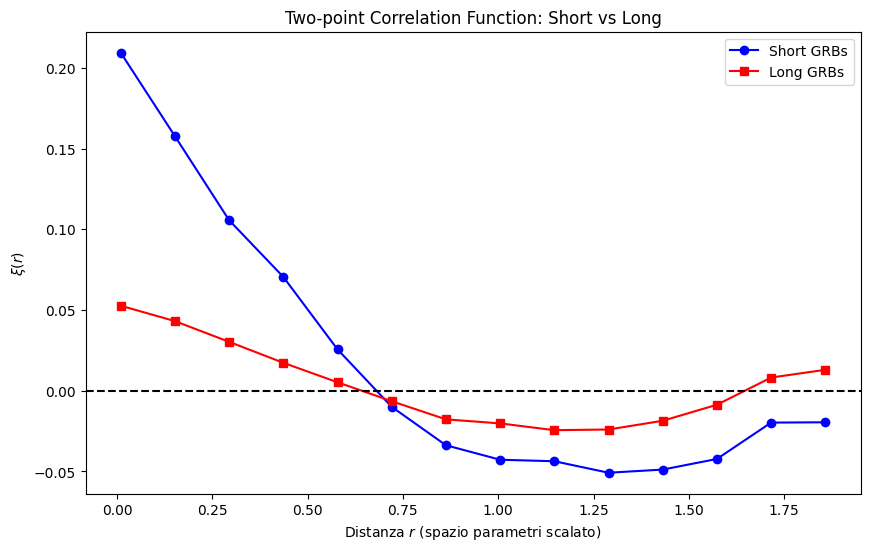

In [61]:
from astroML.correlation import two_point

# Definiamo i bins di distanza r (nello spazio dei parametri scalato)
bins = np.linspace(0.01, 2.0, 15)

# Calcolo per i Short
corr_short = two_point(X_short, bins, method='landy-szalay')

# Calcolo per i Long
corr_long = two_point(X_long, bins, method='landy-szalay')

# Plot dei risultati
plt.figure(figsize=(10, 6))
plt.plot(bins[:-1], corr_short, 'o-', label='Short GRBs', color='blue')
plt.plot(bins[:-1], corr_long, 's-', label='Long GRBs', color='red')

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Distanza $r$ (spazio parametri scalato)')
plt.ylabel('$\\xi(r)$')
plt.title('Two-point Correlation Function: Short vs Long')
plt.legend()
plt.show()

## Trying dimensionality reduction

Explained variance ratio: [0.39306167 0.16146302 0.15729499 0.13022589]
k=2: silhouette=0.352
k=3: silhouette=0.248
k=4: silhouette=0.258
k=5: silhouette=0.279


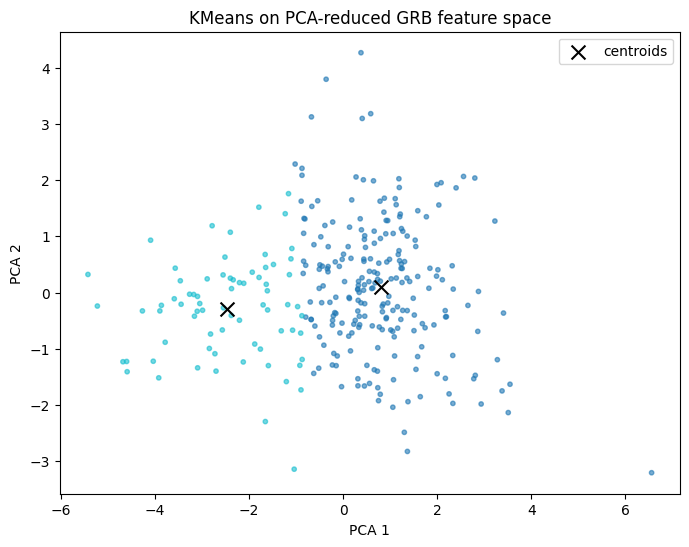

In [77]:
from sklearn.decomposition import PCA

# select numeric features excluding ra/decl and text identifiers
numeric_features = [
     'T90', 'T90_error',
    'fluence', 'fluence_error',
    'redshift', "'T100'", 'mjd_(T0)'
]

df_cluster = pd.DataFrame({
    col: np.array(data_merged[col], dtype=float)
    for col in numeric_features
})

df_cluster['GBM_located'] = np.where(
    np.array(data_merged['GBM_located'], dtype=str) == 'True',
    1,
    0
)

# drop rows with invalid placeholders / missing values
invalid = (df_cluster[numeric_features] == -999) | ~np.isfinite(df_cluster[numeric_features])
df_cluster = df_cluster[~invalid.any(axis=1)].copy()

# log-scale the positive quantities that span many decades
for col in ['T90', 'T90_error', 'fluence', 'fluence_error', "'T100'"]:
    col_name = col.strip("'")
    df_cluster[f'log_{col_name}'] = np.log10(df_cluster[col].clip(lower=1e-12))

features_for_clustering = [
    'log_T90', 'log_T90_error', 'log_fluence', 'log_fluence_error',
    'log_T100',  'redshift', 'mjd_(T0)', 'GBM_located'
]

X_all = df_cluster[features_for_clustering].values
X_all_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=4, random_state=42)
X_pca = pca.fit_transform(X_all_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42).fit(X_pca)
    print(f"k={k}: silhouette={silhouette_score(X_pca, km.labels_):.3f}")

km2 = KMeans(n_clusters=2, n_init='auto', random_state=42).fit(X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=km2.labels_, cmap='tab10', s=10, alpha=0.6)
plt.scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1],
            c='black', marker='x', s=100, label='centroids')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('KMeans on PCA-reduced GRB feature space')
plt.legend()
plt.show()

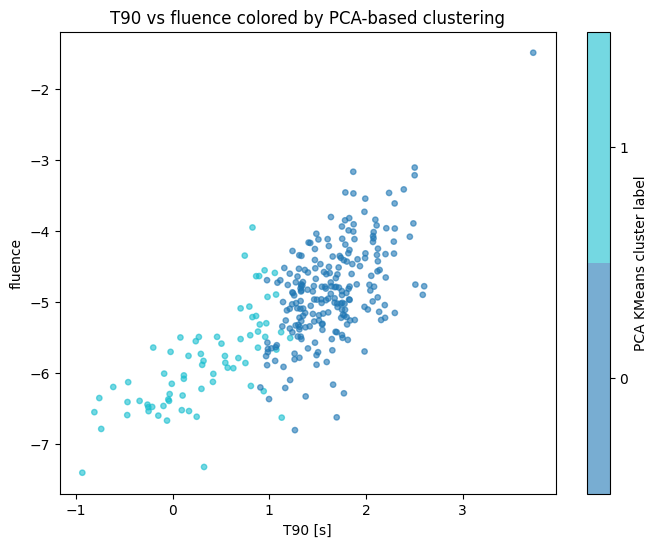

In [78]:
# reconstruct the original feature space from PCA + scaler
X_reconstructed = pca.inverse_transform(X_pca)
X_orig = scaler.inverse_transform(X_reconstructed)

# extract the T90 and fluence log-components
idx_T90 = features_for_clustering.index('log_T90')
idx_fluence = features_for_clustering.index('log_fluence')

log_T90_recon = X_orig[:, idx_T90]
log_fluence_recon = X_orig[:, idx_fluence]

plt.figure(figsize=(8, 6))
plt.scatter(log_T90_recon, log_fluence_recon,
            c=km2.labels_, cmap='tab10', s=15, alpha=0.6)
#plt.xscale('log')
#plt.yscale('log')
plt.xlabel('T90 [s]')
plt.ylabel('fluence')
plt.title('T90 vs fluence colored by PCA-based clustering')
cbar = plt.colorbar(ticks=[0, 1], boundaries=[-0.5, 0.5, 1.5])
cbar.set_label('PCA KMeans cluster label')
plt.show()